In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
train = pd.read_csv('../data/train.csv', parse_dates=['date'])
test = pd.read_csv('../data/test.csv', parse_dates=['date'])
sample_sub = pd.read_csv('../data/sample_submission.csv')


print("--- Данные продаж (Train) ---")
display(train.head())

train.info()
train.describe()

--- Данные продаж (Train) ---


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [61]:

train['day_of_week'] = train['date'].dt.dayofweek
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['sales_lag_1'] = train.groupby(['store', 'item'])['sales'].shift(1)
# продажи ровно неделю назад
train['sales_lag_7'] = train.groupby(['store', 'item'])['sales'].shift(7)
train['sales_lag_30'] = train.groupby(['store', 'item'])['sales'].shift(30)
# Окно в 7 дней (rolling mean)
train['sales_rolling_mean_7'] = train.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())
train['sales_rolling_mean_30'] = train.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=30).mean())
# Профиль магазина за весь период 
store_size = train.groupby('store')['sales'].mean().reset_index()
store_size.columns = ['store', 'store_avg_sales']
# Профиль товара
item_popularity = train.groupby('item')['sales'].mean().reset_index()
item_popularity.columns = ['item', 'item_avg_sales']
# Объединяем за весь период 
cols_to_drop = ['item_avg_sales', 'store_avg_sales']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])

train = train.merge(item_popularity, on='item', how='left')
# Объединяем с основной таблицей
train = train.merge(store_size, on='store', how='left')



manual_holidays = [
    (1, 1), (12, 31), (12, 30),   # Новый год
    (2, 14), (2, 13),             # День Валентина
    (7, 4), (7, 3),               # День независимости
    (10, 31), (10, 30),           # Хэллоуин
    (11, 24), (11, 23),           # Благодарение
    (12, 25), (12, 24), (12, 23)  # Рождество
]

# 2. Создаем функцию для проверки
def check_holiday(row):
    # Проверяем, совпадает ли месяц и день с нашим списком
    if (row.month, row.day) in manual_holidays:
        return 1
    return 0

# 3. Применяем к нашему train
train['is_holiday'] = train['date'].apply(check_holiday)

# 4. Добавим "эффект выходного"
train['is_shopping_day'] = train['day_of_week'].isin([4, 5]).astype(int)


train.dropna(inplace=True)


train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 828500 entries, 15000 to 843499
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   828500 non-null  datetime64[us]
 1   store                  828500 non-null  int64         
 2   item                   828500 non-null  int64         
 3   sales                  828500 non-null  int64         
 4   day_of_week            828500 non-null  int32         
 5   month                  828500 non-null  int32         
 6   year                   828500 non-null  int32         
 7   sales_lag_7            828500 non-null  float64       
 8   sales_rolling_mean_7   828500 non-null  float64       
 9   sales_lag_1            828500 non-null  float64       
 10  is_holiday             828500 non-null  int64         
 11  is_shopping_day        828500 non-null  int64         
 12  sales_rolling_mean_30  828500 non-null  float64    

,date,store,item,sales,day_of_week,month,year,sales_lag_7,sales_rolling_mean_7,sales_lag_1,is_holiday,is_shopping_day,sales_rolling_mean_30,sales_lag_30,item_avg_sales,store_avg_sales
count,828500,828500.000000,828500.000000,828500.00000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000,828500.000000
mean,2015-09-24 23:59:59.999999,5.500000,25.500000,53.41543,3.003018,6.849125,2015.204587,53.449014,53.426798,53.412922,0.040435,0.286059,53.478009,53.523681,53.368204,53.368204
min,2013-06-19 00:00:00,1.000000,1.000000,0.00000,0.000000,1.000000,2013.000000,0.000000,5.571429,0.000000,0.000000,0.000000,7.533333,0.000000,18.762893,37.144861
25%,2014-08-07 00:00:00,3.000000,13.000000,30.00000,1.000000,4.000000,2014.000000,31.000000,31.285714,30.000000,0.000000,0.000000,31.433333,31.000000,30.027208,40.625999
50%,2015-09-25 00:00:00,5.500000,25.500000,48.00000,3.000000,7.000000,2015.000000,48.000000,49.000000,48.000000,0.000000,0.000000,49.200000,48.000000,52.465916,56.155655
75%,2016-11-12 00:00:00,8.000000,38.000000,71.00000,5.000000,10.000000,2016.000000,71.000000,70.857143,71.000000,0.000000,1.000000,70.966667,71.000000,71.110018,60.809389
max,2017-12-31 00:00:00,10.000000,50.000000,231.00000,6.000000,12.000000,2017.000000,231.000000,175.428571,231.000000,1.000000,1.000000,165.800000,231.000000,89.910492,68.445181
std,NaN,2.872283,14.430878,29.11313,1.999244,3.418885,1.324220,29.120506,27.276911,29.112242,0.196976,0.451918,27.043384,29.136604,21.769125,10.507473


--- Отчет по валидационному набору (Декабрь 2017) ---
Дней: 31
Магазинов: 10
Товаров: 50
Всего строк в тесте: 15500
Ожидаемое кол-во (31*10*50): 15500

Последний день обучения: 2017-11-30 00:00:00
Первый день валидации: 2017-12-01 00:00:00


Переключится на ядро с Нампай <2 для выполения


In [ ]:
import sweetviz as sv

report = sv.analyze(train ,pairwise_analysis = 'on')
report.show_html('Report.html')

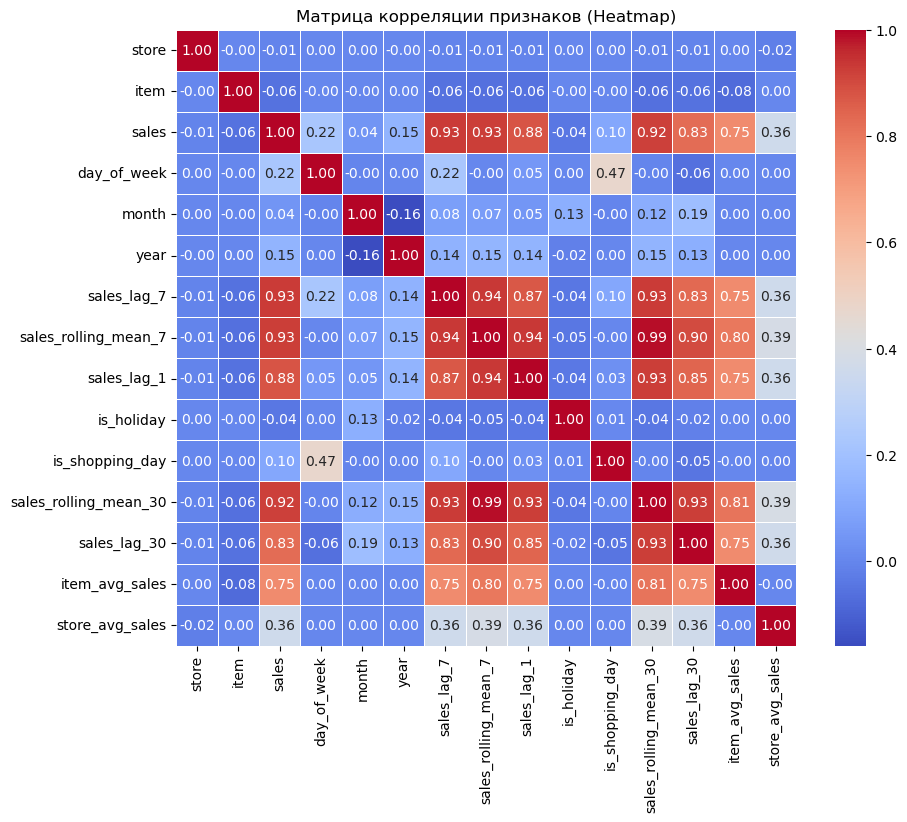

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем только числовые колонки для корреляции
corr_matrix = train.drop('date', axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков (Heatmap)')
plt.show()


Если будем строить линейную не забудь дровнуть item store date так как это линейная комбинация item avg store avg

In [64]:
from catboost import CatBoostRegressor, Pool
train.info()


cat_features = ['store', 'item', 'day_of_week', 'month', 'year', 'is_holiday', 'is_shopping_day']
features = cat_features + ['sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', "sales_rolling_mean_30", "sales_lag_30"]


# 4. СОРТИРОВКА И РАЗБИЕНИЕ (Тайм-сплит)
train = train.sort_values('date')
split_index = int(len(train) * 0.7)

train_df = train.iloc[:split_index]
test_df = train.iloc[split_index:]

# 5. ВЫДЕЛЕНИЕ X и y
X_train, y_train = train_df[features], train_df['sales']
X_val, y_val = test_df[features], test_df['sales']

# 6. СОЗДАНИЕ POOL
train_data = Pool(data=X_train[features], 
                  label=y_train, 
                  cat_features=cat_features)

valid_data = Pool(data=X_val[features], 
                  label=y_val, 
                  cat_features=cat_features)

<class 'pandas.DataFrame'>
RangeIndex: 828500 entries, 15000 to 843499
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   828500 non-null  datetime64[us]
 1   store                  828500 non-null  int64         
 2   item                   828500 non-null  int64         
 3   sales                  828500 non-null  int64         
 4   day_of_week            828500 non-null  int32         
 5   month                  828500 non-null  int32         
 6   year                   828500 non-null  int32         
 7   sales_lag_7            828500 non-null  float64       
 8   sales_rolling_mean_7   828500 non-null  float64       
 9   sales_lag_1            828500 non-null  float64       
 10  is_holiday             828500 non-null  int64         
 11  is_shopping_day        828500 non-null  int64         
 12  sales_rolling_mean_30  828500 non-null  float64    

In [65]:
model = CatBoostRegressor(iterations=500, eval_metric='MAE', verbose=100)
model.fit(train_data, eval_set=valid_data)

Learning rate set to 0.211046
0:	learn: 18.6034846	test: 20.1883122	best: 20.1883122 (0)	total: 158ms	remaining: 1m 18s
100:	learn: 5.7477084	test: 6.3928484	best: 6.3096176 (81)	total: 15.4s	remaining: 1m
200:	learn: 5.6464995	test: 6.6410456	best: 6.3096176 (81)	total: 31.1s	remaining: 46.3s
300:	learn: 5.6066077	test: 6.9104127	best: 6.3096176 (81)	total: 46.7s	remaining: 30.9s
400:	learn: 5.5820487	test: 7.0818096	best: 6.3096176 (81)	total: 1m 2s	remaining: 15.4s
499:	learn: 5.5635297	test: 7.2701563	best: 6.3096176 (81)	total: 1m 18s	remaining: 0us

bestTest = 6.309617625
bestIteration = 81

Shrink model to first 82 iterations.


CatBoostRegressor(eval_metric='MAE', iterations=500, loss_function='RMSE', verbose=100)

In [67]:
model = CatBoostRegressor(
    iterations=1000,          
    eval_metric='MAE',
    task_type="GPU",          
    devices='0',             
    verbose=100,
    early_stopping_rounds=100 
)

model.fit(train_data, eval_set=valid_data)

Learning rate set to 0.123469


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 20.2321597	test: 21.9886824	best: 21.9886824 (0)	total: 904ms	remaining: 15m 3s
100:	learn: 5.8141758	test: 6.3386542	best: 6.3271766 (81)	total: 1m 20s	remaining: 12m
bestTest = 6.327176624
bestIteration = 81
Shrink model to first 82 iterations.


CatBoostRegressor(devices='0', early_stopping_rounds=100, eval_metric='MAE', iterations=1000, loss_function='RMSE', task_type='GPU', verbose=100)

In [68]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.1,
    depth=6,
    loss_function='MAE',        # Теперь модель ОБУЧАЕТСЯ минимизировать MAE
    eval_metric='MAE',          # И ПРОВЕРЯЕТ себя тоже по MAE
    task_type="GPU",
    early_stopping_rounds=100,
    verbose=100
)

model.fit(train_data, eval_set=valid_data)

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 22.2874920	test: 25.1160692	best: 25.1160692 (0)	total: 20.5ms	remaining: 40.9s
100:	learn: 18.8369118	test: 21.6029994	best: 21.6029994 (100)	total: 1.72s	remaining: 32.4s
200:	learn: 15.8777636	test: 18.5562382	best: 18.5562382 (200)	total: 3.47s	remaining: 31.1s
300:	learn: 13.4450263	test: 16.0073124	best: 16.0073124 (300)	total: 5.11s	remaining: 28.8s
400:	learn: 11.5371127	test: 13.9591541	best: 13.9591541 (400)	total: 6.75s	remaining: 26.9s
500:	learn: 10.1082007	test: 12.3645534	best: 12.3645534 (500)	total: 8.39s	remaining: 25.1s
600:	learn: 9.0719407	test: 11.1458379	best: 11.1458379 (600)	total: 10s	remaining: 23.4s
700:	learn: 8.3296741	test: 10.2074935	best: 10.2074935 (700)	total: 11.9s	remaining: 22.1s
800:	learn: 7.7831727	test: 9.4485576	best: 9.4485576 (800)	total: 13.8s	remaining: 20.7s
900:	learn: 7.3696439	test: 8.8297385	best: 8.8297385 (900)	total: 15.7s	remaining: 19.1s
1000:	learn: 7.0485637	test: 8.3314414	best: 8.3314414 (1000)	total: 17.4s	remainin

CatBoostRegressor(depth=6, early_stopping_rounds=100, eval_metric='MAE', iterations=2000, learning_rate=0.1, loss_function='MAE', task_type='GPU', verbose=100)

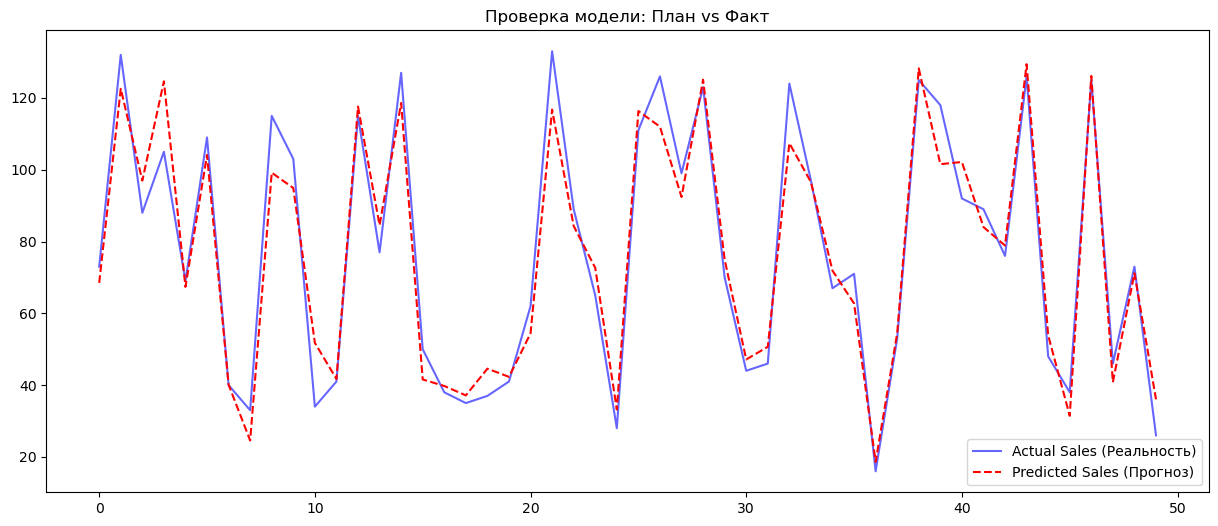

In [69]:
import matplotlib.pyplot as plt

# Возьмем небольшой кусочек тестовых данных для графика (например, первые 100 точек)
sample_size = 50
y_pred = model.predict(X_val)

plt.figure(figsize=(15, 6))
plt.plot(y_val.values[:sample_size], label='Actual Sales (Реальность)', color='blue', alpha=0.6)
plt.plot(y_pred[:sample_size], label='Predicted Sales (Прогноз)', color='red', linestyle='--')
plt.title('Проверка модели: План vs Факт')
plt.legend()
plt.show()

In [71]:
import pandas as pd
import numpy as np

# Список лет для теста
years = [2014, 2015, 2016, 2017]
scores = []

# ВАЖНО: Работаем с копией исходных данных без заранее посчитанных лагов
df_raw = train.copy().drop(columns=['sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', 'sales_rolling_mean_30'], errors='ignore')

for test_year in years:
    # 1. Отсекаем данные: всё до конца тестового года
    current_df = df_raw[df_raw['year'] <= test_year].copy()
    
    # 2. ПЕРЕСЧИТЫВАЕМ фичи только внутри этого окна
    # Так мы гарантируем, что для 2015 года используются только данные 2014-го и т.д.
    current_df['sales_lag_1'] = current_df.groupby(['store', 'item'])['sales'].shift(1)
    current_df['sales_lag_7'] = current_df.groupby(['store', 'item'])['sales'].shift(7)
    current_df['sales_rolling_mean_7'] = current_df.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    current_df['sales_rolling_mean_30'] = current_df.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=30).mean()
    )
    
    # Убираем пустые строки (первые 30 дней, где лаги еще не накопились)
    current_df = current_df.dropna(subset=['sales_rolling_mean_30'])
    
    # 3. Разделяем на Train и Test внутри текущего фолда
    train_fold = current_df[current_df['year'] < test_year]
    test_fold = current_df[current_df['year'] == test_year]
    
    # 4. Обучение
    train_pool = Pool(train_fold[features], train_fold['sales'], cat_features=cat_features)
    test_pool = Pool(test_fold[features], test_fold['sales'], cat_features=cat_features)
    
    model_fold = CatBoostRegressor(
        iterations=1000, learning_rate=0.1, loss_function='MAE', 
        eval_metric='MAE', task_type="GPU", verbose=0
    )
    
    model_fold.fit(train_pool, eval_set=test_pool)
    
    best_score = model_fold.get_best_score()['validation']['MAE']
    scores.append(best_score)
    print(f"Год {test_year}: Честный MAE = {best_score:.4f}")

print(f"\nИтоговый честный средний MAE: {np.mean(scores):.4f}")

Default metric period is 5 because MAE is/are not implemented for GPU


Год 2014: Честный MAE = 7.2438


Default metric period is 5 because MAE is/are not implemented for GPU


Год 2015: Честный MAE = 7.2392


Default metric period is 5 because MAE is/are not implemented for GPU


Год 2016: Честный MAE = 8.1770


Default metric period is 5 because MAE is/are not implemented for GPU


Год 2017: Честный MAE = 8.5546

Итоговый честный средний MAE: 7.8036


В ячейках выше произошел data leaking в вычеслениях скользящих средних. Мне больно их стирать так что оставим, но перепишем код нормально:

In [78]:
# ─────────────────────────────────────────────
# ОБНОВЛЕННЫЙ ЦИКЛ: WALK-FORWARD VALIDATION (С ИСПРАВЛЕНИЕМ)
# ─────────────────────────────────────────────

# Начинаем после первого года данных
start_date = train["date"].min() + pd.DateOffset(months=11)
end_date = train["date"].max()

# Список дат начала месяцев для прогноза
cutoffs = pd.date_range(start=start_date, end=end_date, freq="MS")

all_fold_metrics = []
all_forecasts = []

for i, cutoff in enumerate(cutoffs):
    # 1. Разделение на Train и Test
    # Обучаемся на всём, что было ДО текущего месяца
    train_fold = train[train["date"] < cutoff].copy()
    # Тестируем строго на ОДНОМ следующем месяце
    test_fold = train[(train["date"] >= cutoff) & (train["date"] < cutoff + pd.DateOffset(months=1))].copy()
    
    if test_fold.empty:
        continue

    print(f"\n>>> Fold {i+1} | Train до: {cutoff.date()} | Test: {test_fold['date'].dt.month.iloc[0]}.{test_fold['date'].dt.year.iloc[0]}")

    # 2. ПЕРЕСЧЕТ ПРИЗНАКОВ (Борьба с Leakage + Исправление ошибки дублей)
    # Удаляем старые средние, если они прилипли из исходного датасета
    cols_to_drop = ["store_avg_sales", "item_avg_sales", "sales_lag_1", "sales_lag_7", 
                    "sales_lag_30", "sales_rolling_mean_7", "sales_rolling_mean_30"]
    
    train_fold = train_fold.drop(columns=[c for c in cols_to_drop if c in train_fold.columns])
    test_fold = test_fold.drop(columns=[c for c in cols_to_drop if c in test_fold.columns])

    # Считаем статику только на основе TRAIN
    s_avg = train_fold.groupby("store")["sales"].mean().rename("store_avg_sales")
    i_avg = train_fold.groupby("item")["sales"].mean().rename("item_avg_sales")
    
    train_fold = train_fold.join(s_avg, on="store").join(i_avg, on="item")
    test_fold = test_fold.join(s_avg, on="store").join(i_avg, on="item")
    
    # Добавляем лаги для обучения (shift работает по имеющимся данным)
    train_fold = add_lag_features(train_fold).dropna()

    # 3. ОБУЧЕНИЕ (Loss = RMSE)
    X_tr, y_tr = train_fold[FEATURES], train_fold["sales"]
    
    # Валидационный сет — последний доступный месяц трейна (ноябрь перед декабрем и т.д.)
    val_cutoff = cutoff - pd.DateOffset(months=1)
    val_mask = train_fold["date"] >= val_cutoff
    
    # Если вдруг данных для валидации мало, берем последние 20% трейна
    if val_mask.sum() < 100:
        val_mask = train_fold.index >= train_fold.index.max() * 0.8

    X_val = train_fold[val_mask][FEATURES]
    y_val = train_fold[val_mask]["sales"]
    
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE', 
        eval_metric='RMSE',
        task_type="GPU",       # Убедись, что GPU доступна, иначе смени на CPU
        early_stopping_rounds=50,
        verbose=0
    )
    
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    # 4. РЕКУРСИВНЫЙ ПРОГНОЗ
    # Берем историю продаж для лагов
    history = train_fold[["date", "store", "item", "sales"]].copy()
    
    # Очищаем тест от реальных продаж (оставляем только структуру для заполнения)
    # Используем твою функцию recursive_forecast_month
    forecast_df = recursive_forecast_month(model, history, test_fold)
    
    # 5. СЧИТАЕМ МЕТРИКИ
    y_true = forecast_df["sales"]
    y_pred = forecast_df["predicted_sales"]
    
    m_mae = mean_absolute_error(y_true, y_pred)
    m_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    m_mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    all_fold_metrics.append({
        "Month": cutoff.strftime('%Y-%m'),
        "MAE": m_mae,
        "RMSE": m_rmse,
        "MAPE_%": m_mape
    })
    print(f"   Metrics -> MAE: {m_mae:.2f}, RMSE: {m_rmse:.2f}, MAPE: {m_mape:.2f}%")

# 6. ФИНАЛЬНЫЙ ОТЧЕТ
metrics_results = pd.DataFrame(all_fold_metrics)
print("\n" + "="*50)
print("ИТОГОВАЯ ТАБЛИЦА WALK-FORWARD ВАЛИДАЦИИ")
print("="*50)
print(metrics_results.to_string(index=False, float_format="{:.2f}".format))
print("-"*50)
print(f"AVG MAE:  {metrics_results['MAE'].mean():.2f}")
print(f"AVG RMSE: {metrics_results['RMSE'].mean():.2f}")
print(f"AVG MAPE: {metrics_results['MAPE_%'].mean():.2f}%")


>>> Fold 1 | Train до: 2013-12-01 | Test: 12.2013
   Metrics -> MAE: 15.86, RMSE: 18.36, MAPE: 56.19%

>>> Fold 2 | Train до: 2014-01-01 | Test: 1.2014
   Metrics -> MAE: 4.66, RMSE: 5.99, MAPE: 259211027260140.81%

>>> Fold 3 | Train до: 2014-02-01 | Test: 2.2014
   Metrics -> MAE: 5.06, RMSE: 6.63, MAPE: 15.73%

>>> Fold 4 | Train до: 2014-03-01 | Test: 3.2014
   Metrics -> MAE: 5.78, RMSE: 7.60, MAPE: 14.56%

>>> Fold 5 | Train до: 2014-04-01 | Test: 4.2014
   Metrics -> MAE: 6.25, RMSE: 8.19, MAPE: 13.50%

>>> Fold 6 | Train до: 2014-05-01 | Test: 5.2014
   Metrics -> MAE: 6.12, RMSE: 7.95, MAPE: 12.60%

>>> Fold 7 | Train до: 2014-06-01 | Test: 6.2014
   Metrics -> MAE: 6.37, RMSE: 8.35, MAPE: 12.05%

>>> Fold 8 | Train до: 2014-07-01 | Test: 7.2014
   Metrics -> MAE: 6.56, RMSE: 8.55, MAPE: 11.94%

>>> Fold 9 | Train до: 2014-08-01 | Test: 8.2014
   Metrics -> MAE: 6.38, RMSE: 8.23, MAPE: 13.41%

>>> Fold 10 | Train до: 2014-09-01 | Test: 9.2014
   Metrics -> MAE: 5.72, RMSE: 7.

🚀 Запуск быстрого фолда...
Train: до 2017-12-01 | Test: Декабрь 2017

✅ Результаты фолда:
MAE: 5.99 | RMSE: 7.74 | MAPE: 15.72%


C:\Users\E_V_Z\AppData\Local\Temp\ipykernel_17040\3375505442.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', ax=ax2, palette="viridis")


Text(0.05, 0.95, 'Mean: -0.79\nMedian: -1.12\nStd Dev: 7.70\nIQR: 9.41')

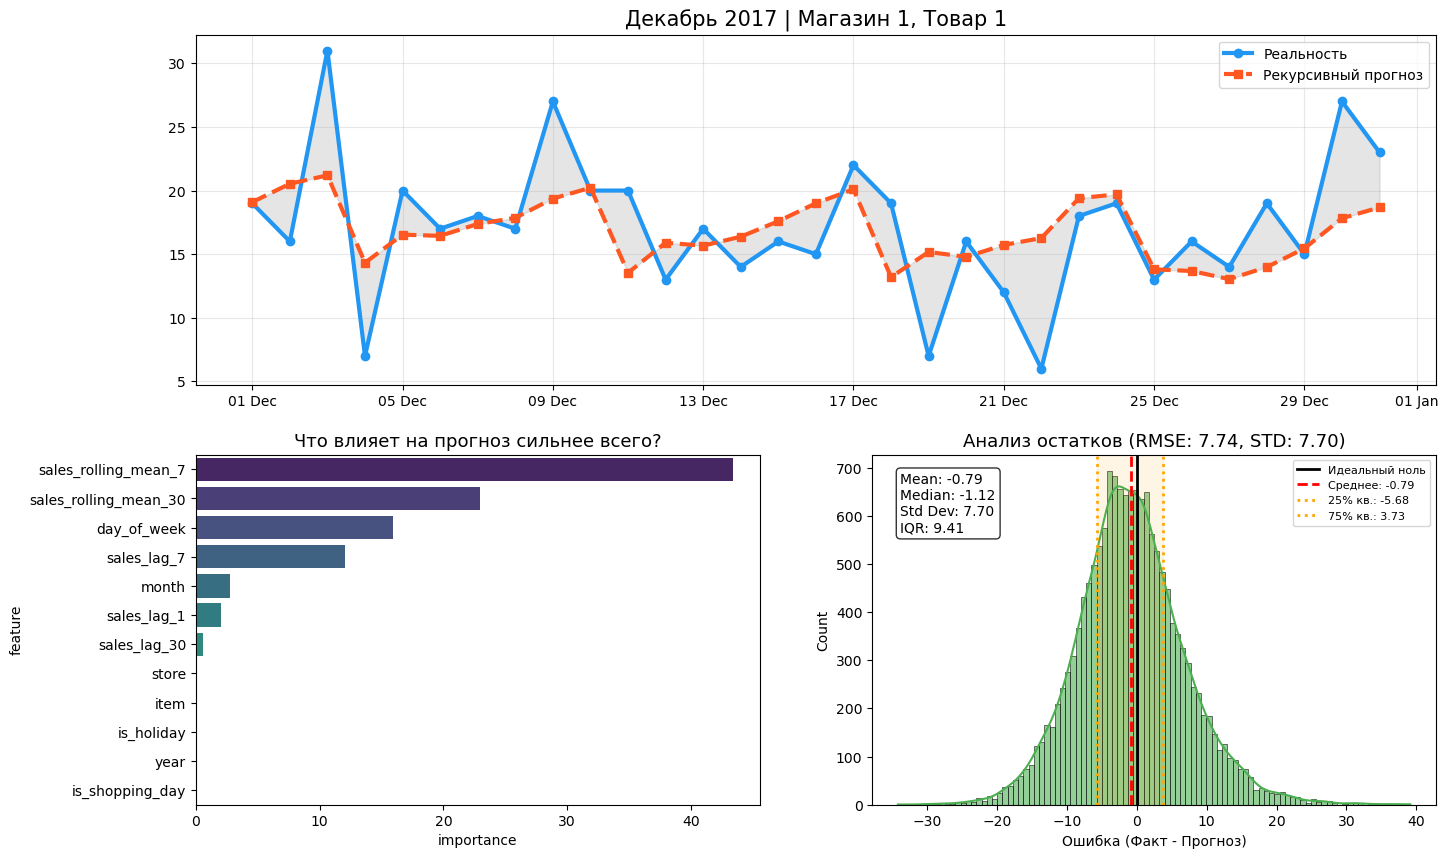

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ─────────────────────────────────────────────
# ОДНОКРАТНЫЙ ЗАПУСК (FINAL FOLD: ДЕКАБРЬ 2017)
# ─────────────────────────────────────────────

# Выбираем последнюю точку для теста (декабрь 2017)
cutoff = train["date"].max() - pd.DateOffset(days=30) 
cutoff = cutoff.replace(day=1) # Округляем до начала месяца

print(f"Запуск...")
print(f"Train: до {cutoff.date()} | Test: Декабрь 2017")

# 1. Разделение
train_fold = train[train["date"] < cutoff].copy()
test_fold = train[train["date"] >= cutoff].copy()

# 2. Пересчет признаков (Честная статика)
cols_to_drop = ["store_avg_sales", "item_avg_sales", "sales_lag_1", "sales_lag_7", 
                "sales_lag_30", "sales_rolling_mean_7", "sales_rolling_mean_30"]

train_fold = train_fold.drop(columns=[c for c in cols_to_drop if c in train_fold.columns])
test_fold = test_fold.drop(columns=[c for c in cols_to_drop if c in test_fold.columns])

s_avg = train_fold.groupby("store")["sales"].mean().rename("store_avg_sales")
i_avg = train_fold.groupby("item")["sales"].mean().rename("item_avg_sales")

train_fold = train_fold.join(s_avg, on="store").join(i_avg, on="item")
test_fold = test_fold.join(s_avg, on="store").join(i_avg, on="item")

# Лаги для обучения
train_fold = add_lag_features(train_fold).dropna()

# 3. Обучение
X_tr, y_tr = train_fold[FEATURES], train_fold["sales"]
val_cutoff = cutoff - pd.DateOffset(months=1)
X_val = train_fold[train_fold["date"] >= val_cutoff][FEATURES]
y_val = train_fold[train_fold["date"] >= val_cutoff]["sales"]

model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    loss_function='RMSE',
    task_type="GPU",
    early_stopping_rounds=50,
    verbose=0
)

model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

# 4. Рекурсивный прогноз
history = train_fold[["date", "store", "item", "sales"]].copy()
forecast_df = recursive_forecast_month(model, history, test_fold)

# 5. Метрики (с исправлением MAPE)
y_true = forecast_df["sales"]
y_pred = forecast_df["predicted_sales"]

m_mae = mean_absolute_error(y_true, y_pred)
m_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Заменяем MAPE на "безопасный" вариант, чтобы не делить на 0
m_mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100 

print(f"\n✅ Результаты фолда:")
print(f"MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | MAPE: {m_mape:.2f}%")

# ─────────────────────────────────────────────


C:\Users\E_V_Z\AppData\Local\Temp\ipykernel_17040\1129530831.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', ax=ax2, palette="viridis")


Text(0.05, 0.95, 'Mean: -0.79\nMedian: -1.12\nStd Dev: 7.70\nIQR: 9.41')

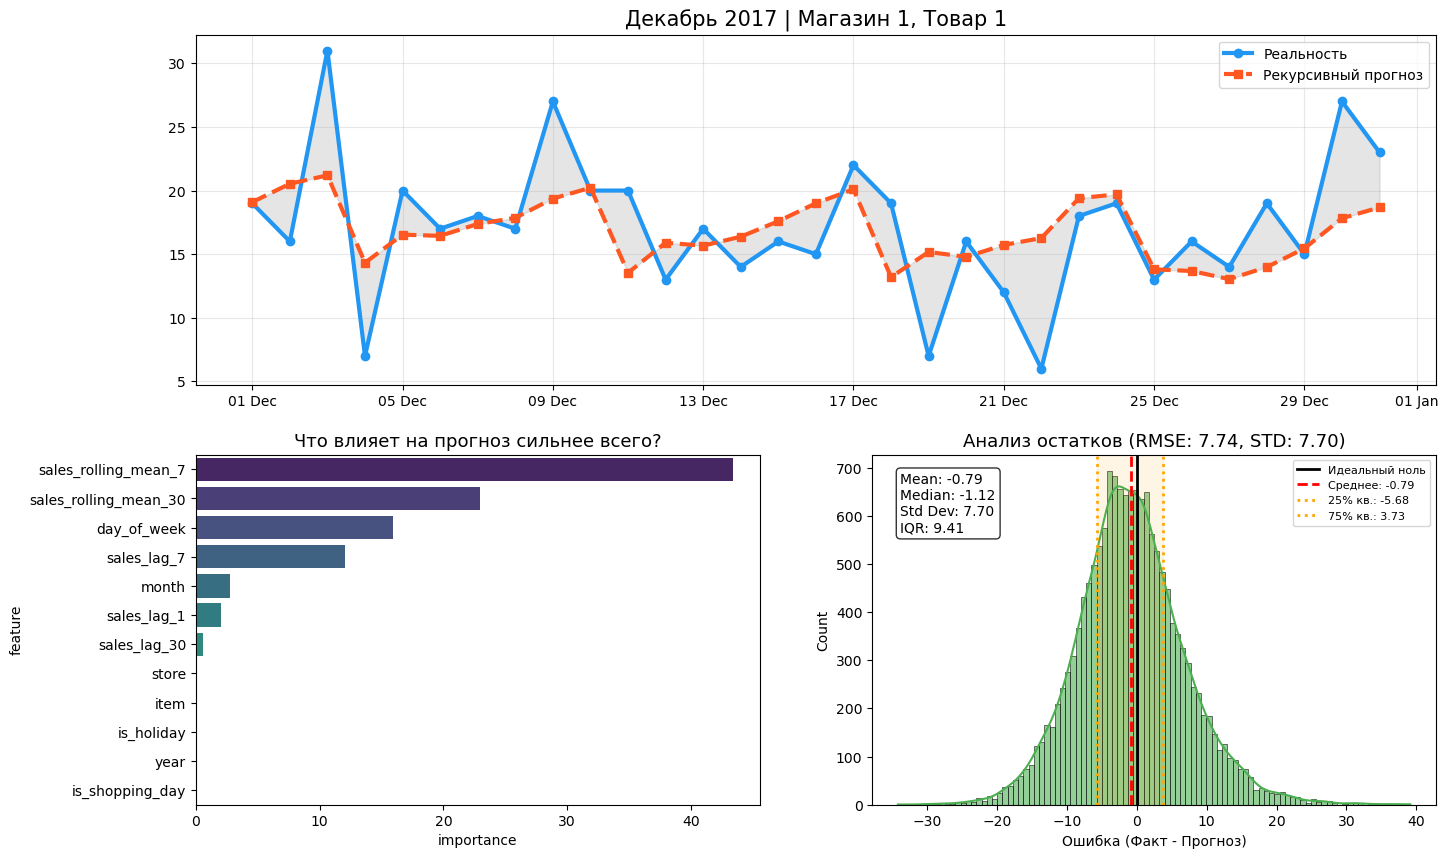

In [82]:
# 6. ВИЗУАЛИЗАЦИЯ
# ─────────────────────────────────────────────

# Подготовка данных для графика (Store 1, Item 1)
SAMPLE_STORE = 1
SAMPLE_ITEM = 1
sample = forecast_df[(forecast_df["store"] == SAMPLE_STORE) & 
                     (forecast_df["item"] == SAMPLE_ITEM)].sort_values("date")

# Создаем сетку графиков
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

# --- ГРАФИК 1: Прогноз vs Реальность ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sample["date"], sample["sales"], label="Реальность", color="#2196F3", lw=3, marker='o')
ax1.plot(sample["date"], sample["predicted_sales"], label="Рекурсивный прогноз", 
         color="#FF5722", lw=3, ls="--", marker='s')
ax1.fill_between(sample["date"], sample["sales"], sample["predicted_sales"], color='gray', alpha=0.2)
ax1.set_title(f"Декабрь 2017 | Магазин {SAMPLE_STORE}, Товар {SAMPLE_ITEM}", fontsize=15)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# --- ГРАФИК 2: Важность признаков (Мой вклад) ---
ax2 = fig.add_subplot(gs[1, 0])
importance = pd.DataFrame({'feature': FEATURES, 'importance': model.get_feature_importance()})
importance = importance.sort_values('importance', ascending=False)
sns.barplot(data=importance, x='importance', y='feature', ax=ax2, palette="viridis")
ax2.set_title("Что влияет на прогноз сильнее всего?", fontsize=13)

# --- ГРАФИК 3: Расширенное распределение ошибок ---
ax3 = fig.add_subplot(gs[1, 1])
errors = y_true - y_pred

# Считаем статистики
mean_err = np.mean(errors)
std_err = np.std(errors)
q25, q50, q75 = np.percentile(errors, [25, 50, 75])

# Рисуем гистограмму
sns.histplot(errors, kde=True, ax=ax3, color="#4CAF50", alpha=0.6)

# Добавляем вертикальные линии
ax3.axvline(0, color='black', lw=2, label='Идеальный ноль')
ax3.axvline(mean_err, color='red', ls='--', lw=2, label=f'Среднее: {mean_err:.2f}')
ax3.axvline(q25, color='orange', ls=':', lw=2, label=f'25% кв.: {q25:.2f}')
ax3.axvline(q75, color='orange', ls=':', lw=2, label=f'75% кв.: {q75:.2f}')

# Заливка зоны "типичной ошибки" (Interquartile Range)
ax3.axvspan(q25, q75, color='orange', alpha=0.1)

ax3.set_title(f"Анализ остатков (RMSE: {m_rmse:.2f}, STD: {std_err:.2f})", fontsize=13)
ax3.set_xlabel("Ошибка (Факт - Прогноз)")
ax3.legend(fontsize=8, loc='upper right')

# Добавим текст с пояснением прямо на график
textstr = '\n'.join((
    f'Mean: {mean_err:.2f}',
    f'Median: {q50:.2f}',
    f'Std Dev: {std_err:.2f}',
    f'IQR: {q75-q25:.2f}'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

Надстроим систему по прогнозированию закупок товара в конеретном магазине.

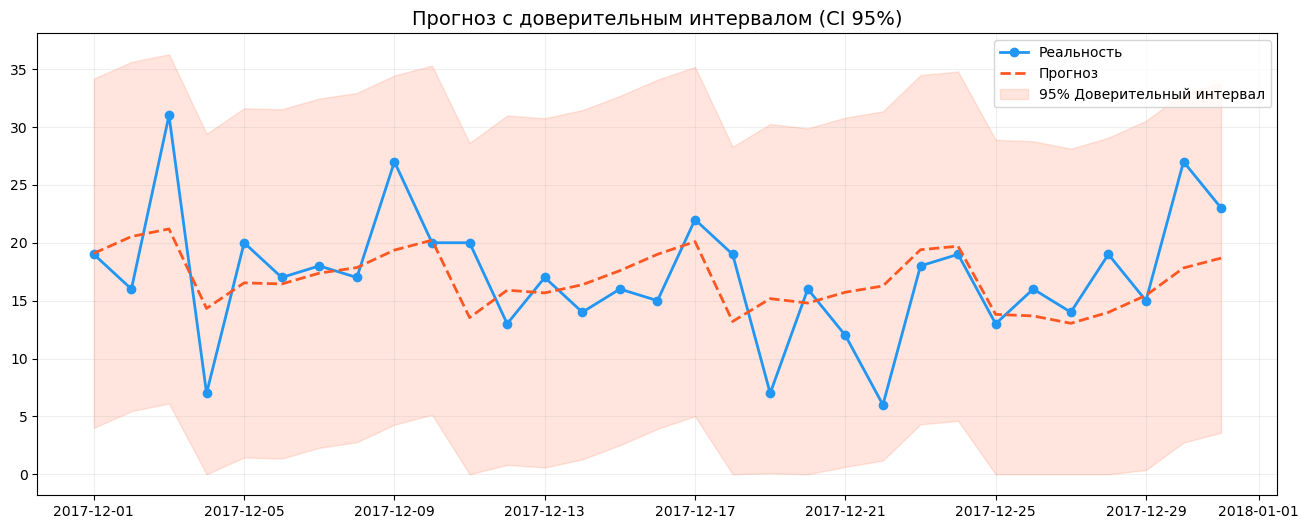

In [83]:
# Коэффициент для 95% уверенности
Z = 1.96 

# Добавляем границы в прогноз
sample["lower_ci"] = np.maximum(0, sample["predicted_sales"] - Z * std_err)
sample["upper_ci"] = sample["predicted_sales"] + Z * std_err

# Теперь визуализируем это красиво
fig, ax = plt.subplots(figsize=(16, 6))

# Реальность и прогноз
ax.plot(sample["date"], sample["sales"], label="Реальность", color="#2196F3", lw=2, marker='o')
ax.plot(sample["date"], sample["predicted_sales"], label="Прогноз", color="#FF5722", lw=2, ls="--")

# Закрашиваем Доверительный Интервал (Зона неопределенности)
ax.fill_between(
    sample["date"], 
    sample["lower_ci"], 
    sample["upper_ci"], 
    color='#FF5722', 
    alpha=0.15, 
    label="95% Доверительный интервал"
)

ax.set_title(f"Прогноз с доверительным интервалом (CI 95%)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

Пробуем построить доверительный интервал через предстказания модели, сделав его динамичным

In [87]:
def recursive_forecast_month(model, history_df, forecast_dates_df):
    """
    Версия с поддержкой MultiQuantile (3 колонки прогноза).
    """
    # Рабочий буфер: история продаж
    buffer = history_df[["date", "store", "item", "sales"]].copy()
    
    # Уникальные пары магазин-товар
    pairs = forecast_dates_df[["store", "item"]].drop_duplicates()
    results = []
    forecast_days = sorted(forecast_dates_df["date"].unique())

    for day in forecast_days:
        day_rows = forecast_dates_df[forecast_dates_df["date"] == day].copy()

        # ── Пересчитываем лаги вручную ──────────────────────────────────────
        cutoff_date = day - pd.Timedelta(days=31)
        recent = buffer[buffer["date"] >= cutoff_date].copy()

        lag_rows = []
        for _, pair_row in pairs.iterrows():
            s, i = pair_row["store"], pair_row["item"]
            hist = recent[(recent["store"] == s) & (recent["item"] == i)].sort_values("date")
            
            # Вспомогательная функция для лага
            def get_lag(n):
                target = day - pd.Timedelta(days=n)
                val = hist[hist["date"] == target]["sales"].values
                return val[0] if len(val) > 0 else np.nan

            l1, l7, l30 = get_lag(1), get_lag(7), get_lag(30)
            
            # Rolling mean
            w7 = hist[(hist["date"] >= day - pd.Timedelta(days=7)) & (hist["date"] < day)]["sales"].values
            w30 = hist[(hist["date"] >= day - pd.Timedelta(days=30)) & (hist["date"] < day)]["sales"].values
            
            lag_rows.append({
                "store": s, "item": i,
                "sales_lag_1": l1, "sales_lag_7": l7, "sales_lag_30": l30,
                "sales_rolling_mean_7": np.mean(w7) if len(w7) > 0 else np.nan,
                "sales_rolling_mean_30": np.mean(w30) if len(w30) > 0 else np.nan
            })

        lag_df = pd.DataFrame(lag_rows)
        day_rows = day_rows.merge(lag_df, on=["store", "item"], how="left")

        # ── ПРЕДСКАЗАНИЕ (Здесь была ошибка!) ───────────────────────────────
        X_day = day_rows[FEATURES]
        preds = model.predict(X_day) # Теперь это (N, 3)
        preds = np.maximum(preds, 0)

        day_rows = day_rows.copy()
        # Раскладываем 3 колонки квантилей
        day_rows["lower_ci"] = preds[:, 0]       # q=0.05
        day_rows["predicted_sales"] = preds[:, 1] # q=0.50 (медиана)
        day_rows["upper_ci"] = preds[:, 2]       # q=0.95

        # ── Обновляем буфер МЕДИАНОЙ ────────────────────────────────────────
        pred_buffer = day_rows[["date", "store", "item"]].copy()
        pred_buffer["sales"] = preds[:, 1] # Для лагов используем медиану
        buffer = pd.concat([buffer, pred_buffer], ignore_index=True)

        results.append(day_rows)

    return pd.concat(results, ignore_index=True)

Делаем "несиметричную" ошибку модели, чтобы она скорее затаваривалась, чем клиент не смог чтото купить. 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns



# Выбираем последнюю точку для теста (декабрь 2017)
cutoff = train["date"].max() - pd.DateOffset(days=30) 
cutoff = cutoff.replace(day=1) # Округляем до начала месяца

print(f"Запуск...")
print(f"Train: до {cutoff.date()} | Test: Декабрь 2017")

# 1. Разделение
train_fold = train[train["date"] < cutoff].copy()
test_fold = train[train["date"] >= cutoff].copy()

# 2. Пересчет признаков (Честная статика)
cols_to_drop = ["store_avg_sales", "item_avg_sales", "sales_lag_1", "sales_lag_7", 
                "sales_lag_30", "sales_rolling_mean_7", "sales_rolling_mean_30"]

train_fold = train_fold.drop(columns=[c for c in cols_to_drop if c in train_fold.columns])
test_fold = test_fold.drop(columns=[c for c in cols_to_drop if c in test_fold.columns])

s_avg = train_fold.groupby("store")["sales"].mean().rename("store_avg_sales")
i_avg = train_fold.groupby("item")["sales"].mean().rename("item_avg_sales")

train_fold = train_fold.join(s_avg, on="store").join(i_avg, on="item")
test_fold = test_fold.join(s_avg, on="store").join(i_avg, on="item")

# Лаги для обучения
train_fold = add_lag_features(train_fold).dropna()

# 3. Обучение
X_tr, y_tr = train_fold[FEATURES], train_fold["sales"]
val_cutoff = cutoff - pd.DateOffset(months=1)
X_val = train_fold[train_fold["date"] >= val_cutoff][FEATURES]
y_val = train_fold[train_fold["date"] >= val_cutoff]["sales"]

model = CatBoostRegressor(
    iterations=1000,
    # Мы ставим 0.6 как "базовый" прогноз (медиану), чтобы модель была чуть оптимистичнее
    # И 0.98 для верхней границы, чтобы почти исключить дефицит
    loss_function='MultiQuantile:alpha=0.05,0.6,0.98', 
    verbose=0
)

model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

# 4. Рекурсивный прогноз
history = train_fold[["date", "store", "item", "sales"]].copy()
forecast_df = recursive_forecast_month(model, history, test_fold)

# 5. Метрики (с исправлением MAPE)
y_true = forecast_df["sales"]
y_pred = forecast_df["predicted_sales"]

m_mae = mean_absolute_error(y_true, y_pred)
m_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Заменяем MAPE на "безопасный" вариант, чтобы не делить на 0
m_mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100 

print(f"\nРезультаты фолда:")
print(f"MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | MAPE: {m_mape:.2f}%")

# ─────────────────────────────────────────────


🚀 Запуск быстрого фолда...
Train: до 2017-12-01 | Test: Декабрь 2017

✅ Результаты фолда:
MAE: 6.84 | RMSE: 8.64 | MAPE: 19.03%


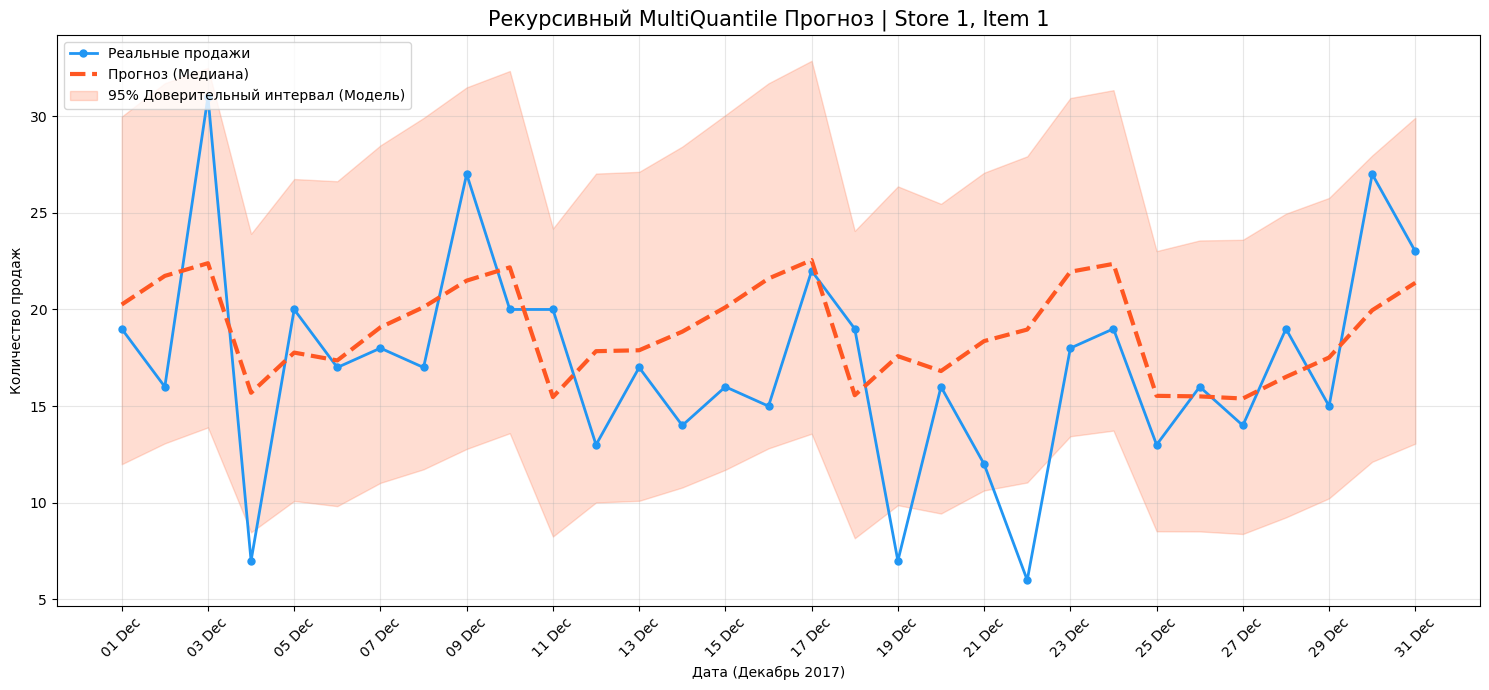

In [97]:
# 1. Выбираем конкретную пару для детального осмотра
SAMPLE_STORE = 1
SAMPLE_ITEM = 1

sample = forecast_df[
    (forecast_df["store"] == SAMPLE_STORE) & 
    (forecast_df["item"] == SAMPLE_ITEM)
].sort_values("date")

# 2. Строим график
plt.figure(figsize=(15, 7))

# Реальные данные (Синие точки)
plt.plot(sample["date"], sample["sales"], 
         label="Реальные продажи", color="#2196F3", lw=2, marker='o', markersize=5)

# Предсказание медианы (Оранжевая пунктирная линия)
plt.plot(sample["date"], sample["predicted_sales"], 
         label="Прогноз (Медиана)", color="#FF5722", lw=3, ls="--")

# ДИНАМИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (MultiQuantile)
plt.fill_between(
    sample["date"], 
    sample["lower_ci"], 
    sample["upper_ci"], 
    color='#FF5722', alpha=0.2, 
    label="95% Доверительный интервал (Модель)"
)

# Оформление
plt.title(f"Рекурсивный MultiQuantile Прогноз | Store {SAMPLE_STORE}, Item {SAMPLE_ITEM}", fontsize=15)
plt.xlabel("Дата (Декабрь 2017)")
plt.ylabel("Количество продаж")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

# Настройка оси X для дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

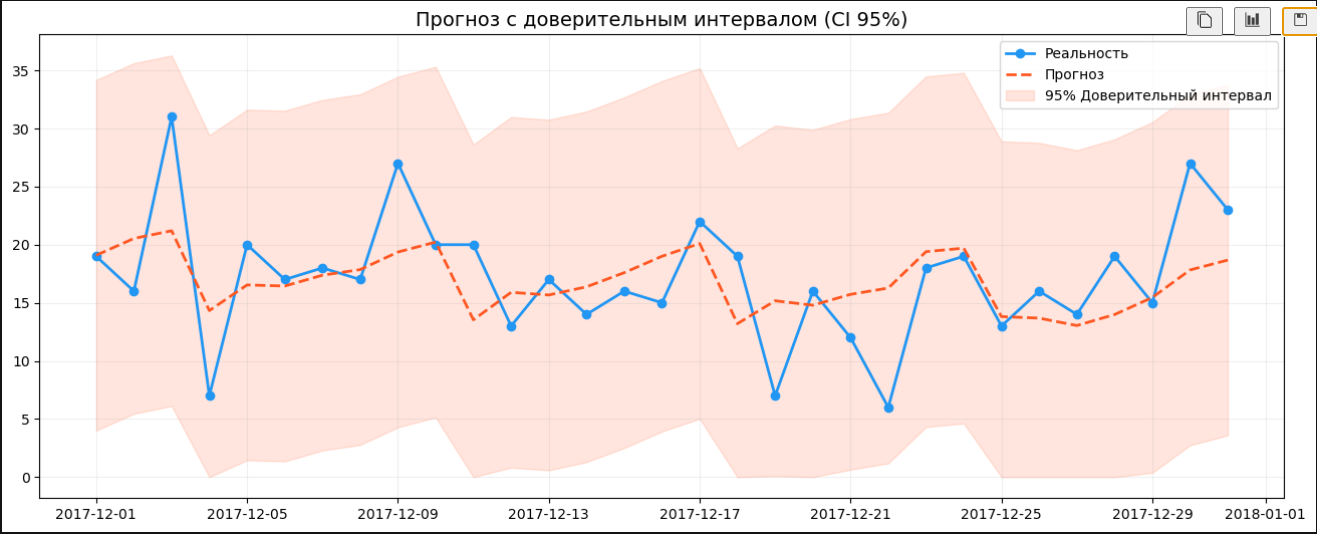

Мы 

In [98]:
def calculate_business_metrics(df, model_name):
    # Допустим, верхняя граница (upper_ci) — это то, сколько мы завезли на склад
    stock_level = df["upper_ci"]
    actual_sales = df["sales"]
    
    # 1. Упущенные продажи (Demand > Stock)
    lost_sales = np.maximum(0, actual_sales - stock_level).sum()
    
    # 2. Излишки (Stock > Demand)
    # Это товары, которые остались лежать на полке в конце дня
    excess_stock = np.maximum(0, stock_level - actual_sales).sum()
    
    # 3. Сервис-левел (какой % спроса мы удовлетворили)
    service_level = (actual_sales.sum() - lost_sales) / actual_sales.sum() * 100
    
    return {
        "Модель": model_name,
        "Упущено продаж (шт)": int(lost_sales),
        "Затоваривание склада (шт)": int(excess_stock),
        "Service Level (%)": f"{service_level:.2f}%"
    }

# Считаем для нашей текущей MultiQuantile модели
mq_metrics = calculate_business_metrics(forecast_df, "MultiQuantile (Динамическая)")

# Для сравнения создадим "глупую" модель со статичным запасом 
# (Прогноз + средняя ошибка из прошлого кода, допустим +10 единиц к прогнозу)
df_static = forecast_df.copy()
static_buffer = 10 # фиксированный запас "на глаз"
df_static["upper_ci"] = df_static["predicted_sales"] + static_buffer
static_metrics = calculate_business_metrics(df_static, "Статичный запас (+10 шт)")

# Итог в таблицу
business_results = pd.DataFrame([mq_metrics, static_metrics])
print(business_results.to_string(index=False))

                      Модель  Упущено продаж (шт)  Затоваривание склада (шт) Service Level (%)
MultiQuantile (Динамическая)                  585                     283167            99.92%
    Статичный запас (+10 шт)                 2761                     219745            99.60%


In [99]:
# Посчитаем среднюю ширину интервала MultiQuantile, 
# чтобы понять, сколько "в среднем" модель добавляет сверху
avg_mq_safety_buffer = (forecast_df["upper_ci"] - forecast_df["predicted_sales"]).mean()

print(f"Средний 'умный' запас MultiQuantile: {avg_mq_safety_buffer:.2f} шт.")

# Теперь создадим модель, которая ВСЕГДА прибавляет именно это число
df_fair_static = forecast_df.copy()
df_fair_static["upper_ci"] = df_fair_static["predicted_sales"] + avg_mq_safety_buffer

fair_metrics = calculate_business_metrics(df_fair_static, f"Честный статик (+{avg_mq_safety_buffer:.1f})")
print("\n=== СРАВНЕНИЕ С ЧЕСТНЫМ ЗАПАСОМ ===")
print(pd.DataFrame([mq_metrics, fair_metrics]).to_string(index=False))

Средний 'умный' запас MultiQuantile: 14.23 шт.

=== СРАВНЕНИЕ С ЧЕСТНЫМ ЗАПАСОМ ===
                      Модель  Упущено продаж (шт)  Затоваривание склада (шт) Service Level (%)
MultiQuantile (Динамическая)                  585                     283167            99.92%
      Честный статик (+14.2)                 1154                     283736            99.83%


Динамическая модель получила уменьшение и упущеных продаж и затоваривания на складе

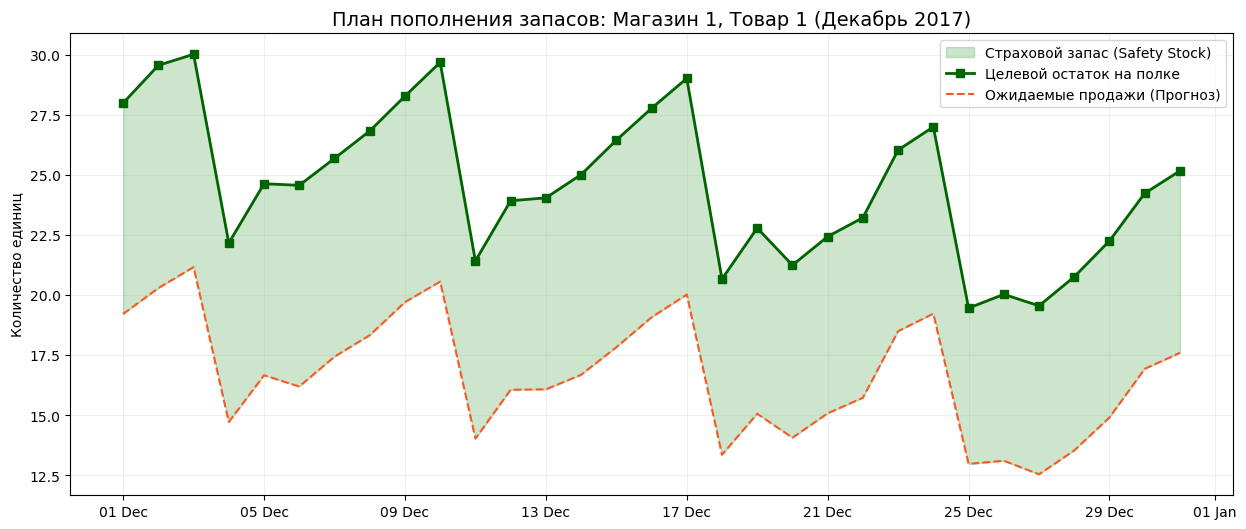

In [92]:
# Выберем топ-товар для примера
s, i = 1, 1
plan = forecast_df[(forecast_df["store"] == s) & (forecast_df["item"] == i)].sort_values("date")

plt.figure(figsize=(15, 6))

# Заливка: Зона страхового запаса (Safety Stock)
plt.fill_between(plan["date"], plan["predicted_sales"], plan["upper_ci"], 
                 color='green', alpha=0.2, label="Страховой запас (Safety Stock)")

# Линия: Необходимый остаток на начало дня
plt.plot(plan["date"], plan["upper_ci"], color='darkgreen', marker='s', lw=2, label="Целевой остаток на полке")

# Линия: Ожидаемые продажи
plt.plot(plan["date"], plan["predicted_sales"], color='#FF5722', ls='--', label="Ожидаемые продажи (Прогноз)")

plt.title(f"План пополнения запасов: Магазин {s}, Товар {i} (Декабрь 2017)", fontsize=14)
plt.ylabel("Количество единиц")
plt.legend()
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()

In [95]:
# 1. Группируем
purchase_order = forecast_df.groupby(["store", "item"]).agg({
    "predicted_sales": "sum",
    "upper_ci": "sum"
}).reset_index()

# 2. Считаем дополнительные поля
purchase_order["order_volume"] = np.ceil(purchase_order["upper_ci"]).astype(int)
purchase_order["predicted_sales_int"] = np.ceil(purchase_order["predicted_sales"]).astype(int)
purchase_order["safety_buffer"] = purchase_order["order_volume"] - purchase_order["predicted_sales_int"]

# 3. Переименовываем только нужные нам колонки
rename_dict = {
    "store": "Магазин",
    "item": "Товар",
    "predicted_sales_int": "Прогноз продаж",
    "order_volume": "Рекомендуемый закуп",
    "safety_buffer": "Страховой запас"
}

# Оставляем только финальный набор колонок в нужном порядке
final_table = purchase_order[list(rename_dict.keys())].rename(columns=rename_dict)

# 5. Вывод
print("ТОП-10 ПОЗИЦИЙ ДЛЯ ЗАКУПКИ НА ДЕКАБРЬ:")
print(final_table.sort_values("Рекомендуемый закуп", ascending=False).head(10).to_string(index=False))

ТОП-10 ПОЗИЦИЙ ДЛЯ ЗАКУПКИ НА ДЕКАБРЬ:
 Магазин  Товар  Прогноз продаж  Рекомендуемый закуп  Страховой запас
       2     28            2717                 3193              476
       2     15            2697                 3171              474
       2     18            2658                 3149              491
       2     13            2621                 3106              485
       8     15            2619                 3101              482
       8     28            2619                 3099              480
       2     45            2591                 3078              487
       2     25            2589                 3076              487
       2     38            2588                 3076              488
       2     22            2582                 3072              490
